Installing lazyslide library

In [1]:
!pip install lazyslide

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 52.7/52.7 kB 2.8 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 79.5/79.5 kB 5.6 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 87.8/87.8 kB 5.4 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 90.6/90.6 kB 4.8 MB/s eta 0:00:00
INFO: pip is looking at multiple versions of s3fs to determine which version is compatible with other requirements. This could take a while.
INFO: pip is still looking at multiple versions of s3fs to determine which version is compatible with other requirements. This could take a while.
INFO: This is taking longer than usual. You might need to provide the dependency resolver with stricter constraints to reduce runtime. See https://pip.pypa.io/warnings/backtracking for guidance. If you want to abort this run, press Ctrl + C.
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 131.9/131.9 kB 6.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━

In [2]:
import lazyslide as zs

In [8]:
slide = "/content/CMU-1-Small-Region.svs"


In [6]:
from wsidata import open_wsi

Wrapping your WSI data inside Lazyslide's WSIData object

WSI: /content/CMU-1-Small-Region.svs
Reader: openslide
Dimensions: 2967×2220 (h×w), 1 Pyramid
Pixel physical size: 0.499 MPP
SpatialData object
with coordinate systems:
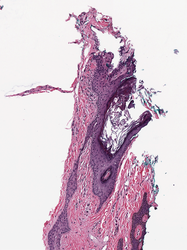

In [10]:
wsi = open_wsi(slide)
wsi

Viewing the properties of the WSI

In [11]:
wsi.properties

Field,Value
shape,"[2967, 2220]"
n_level,1
level_shape,"[[2967, 2220]]"
level_downsample,[1.0]
mpp,0.499
magnification,20.0
bounds,"[0, 0, 2220, 2967]"
scene,0
n_scenes,1
scene_names,['Image 0']


Visualizing the WSI using lazyslide's tissue function

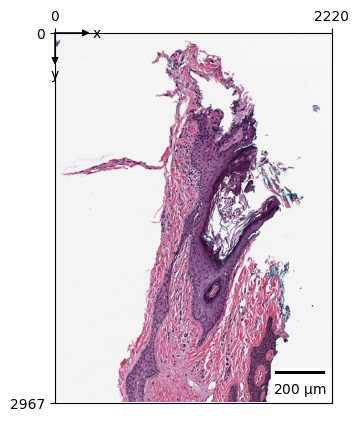

In [12]:
zs.pl.tissue(wsi)

Saving data to disk

In [13]:
wsi.write()

Segmenting tissues from background image

In [14]:
zs.pp.find_tissues(wsi)

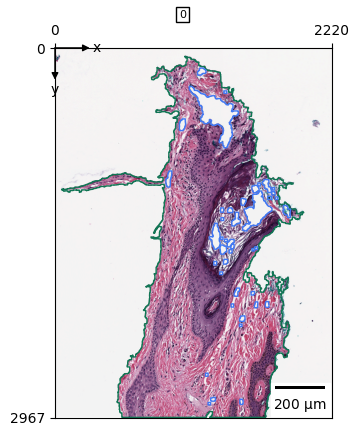

In [15]:
zs.pl.tissue(wsi)

WSI: /content/CMU-1-Small-Region.svs
Reader: openslide
Dimensions: 2967×2220 (h×w), 1 Pyramid
Pixel physical size: 0.499 MPP
SpatialData object, with associated Zarr store: /content/CMU-1-Small-Region.zarr
└── Shapes
      └── 'tissues': GeoDataFrame shape: (1, 2) (2D shapes)
with coordinate systems:
    ▸ 'global', with elements:
        tissues (Shapes)
with the following elements not in the Zarr store:
    ▸ tissues (Shapes)
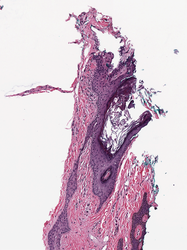

In [16]:
wsi

Displaying Geometric Information of the tissues

In [47]:

wsi["tissues"]

,tissue_id,geometry,area,area_filled,convex_area,solidity,convexity,axis_major_length,axis_minor_length,eccentricity,...,moment-mu21,moment-mu12,moment-mu03,moment-nu20,moment-nu11,moment-nu02,moment-nu30,moment-nu21,moment-nu12,moment-nu03
0,0,"POLYGON ((1044 64, 1044 65, 1044 66, 1044 67, ...",2401628.5,2569815.0,4138653.5,0.580292,1.72327,2840.658203,1535.971069,0.841209,...,4.614045e+13,-7.060252e+13,-2.758312e+14,0.037657,-0.006227,0.23431,-0.001321,0.004358,-0.006669,-0.026055


In [18]:
wsi.write()

Using Lazyslide's advanced  Deep learning-based tissue segmentation

In [19]:
zs.seg.tissue(wsi, key_added="dl-tissues")

PathProfiler/PathProfiler_tissue_seg_exp(…): reconstructing file:   0%|          |  0.00B /  208MB            

PathProfiler/PathProfiler_tissue_seg_exp(…): downloading bytes:           |  0.00B            

WSI: /content/CMU-1-Small-Region.svs
Reader: openslide
Dimensions: 2967×2220 (h×w), 1 Pyramid
Pixel physical size: 0.499 MPP
SpatialData object, with associated Zarr store: /content/CMU-1-Small-Region.zarr
└── Shapes
      ├── 'dl-tissues': GeoDataFrame shape: (2, 2) (2D shapes)
      └── 'tissues': GeoDataFrame shape: (1, 2) (2D shapes)
with coordinate systems:
    ▸ 'global', with elements:
        dl-tissues (Shapes), tissues (Shapes)
with the following elements not in the Zarr store:
    ▸ dl-tissues (Shapes)
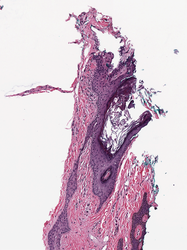

In [20]:
wsi

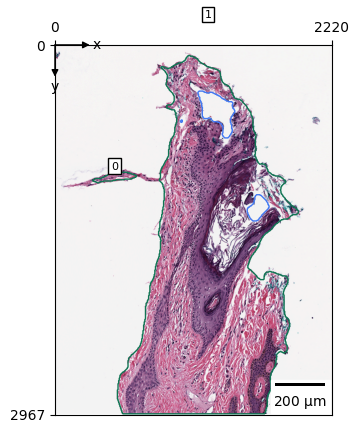

In [21]:
zs.pl.tissue(wsi, tissue_key="dl-tissues")

Calculating the various geometric properties of each tissue piece

In [22]:
zs.tl.tissue_props(wsi)

In [23]:
wsi["tissues"]

,tissue_id,geometry,area,area_filled,convex_area,solidity,convexity,axis_major_length,axis_minor_length,eccentricity,...,moment-mu21,moment-mu12,moment-mu03,moment-nu20,moment-nu11,moment-nu02,moment-nu30,moment-nu21,moment-nu12,moment-nu03
0,0,"POLYGON ((1044 64, 1044 65, 1044 66, 1044 67, ...",2401628.5,2569815.0,4138653.5,0.580292,1.72327,2840.658203,1535.971069,0.841209,...,4.614045e+13,-7.060252e+13,-2.758312e+14,0.037657,-0.006227,0.23431,-0.001321,0.004358,-0.006669,-0.026055


Tiling/ Breaking down our tissues into patches

In [31]:
zs.pp.tile_tissues(wsi, 254, mpp=0.5)
wsi.tile_spec("tiles")

Tile at 0.5 mpp, 254×254 (h×w)
Stride: 254×254 (0×0 overlap)
Operation size: 254×254, level=0
Base size: 254×254, level=0
Target tissue: 'tissues'

In [48]:
# Overlapping our pixels to allow deep learning models learn context from neighboring region

zs.pp.tile_tissues(wsi, 254, overlap=0.1, mpp=0.5, key_added="tile_overlap_0.1")
wsi.tile_spec("tile_overlap_0.1")

Tile at 0.5 mpp, 254×254 (h×w)
Stride: 228×228 (26×26 overlap)
Operation size: 254×254, level=0
Base size: 254×254, level=0
Target tissue: 'tissues'

In [33]:
wsi['tiles']

,tile_id,tissue_id,geometry
0,0,0,"POLYGON ((813 2605, 813 2859, 559 2859, 559 26..."
1,1,0,"POLYGON ((1067 1081, 1067 1335, 813 1335, 813 ..."
2,2,0,"POLYGON ((1067 1335, 1067 1589, 813 1589, 813 ..."
3,3,0,"POLYGON ((1067 1589, 1067 1843, 813 1843, 813 ..."
4,4,0,"POLYGON ((1067 1843, 1067 2097, 813 2097, 813 ..."
5,5,0,"POLYGON ((1067 2097, 1067 2351, 813 2351, 813 ..."
6,6,0,"POLYGON ((1067 2351, 1067 2605, 813 2605, 813 ..."
7,7,0,"POLYGON ((1067 2605, 1067 2859, 813 2859, 813 ..."
8,8,0,"POLYGON ((1321 573, 1321 827, 1067 827, 1067 5..."
9,9,0,"POLYGON ((1321 827, 1321 1081, 1067 1081, 1067..."


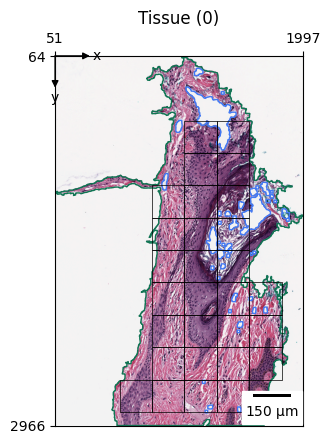

In [34]:
zs.pl.tiles(wsi, tissue_id=0, linewidth=0.5)

Evaluating the quality of tiles using a QC model from pathprofiler

In [35]:
zs.tl.tile_prediction(wsi, 'pathprofilerqc')

PathProfiler/PathProfiler_patch_quality_(…): reconstructing file:   0%|          |  0.00B / 46.2MB            

PathProfiler/PathProfiler_patch_quality_(…): downloading bytes:           |  0.00B            

Output()

In [36]:
wsi['tiles']

,tile_id,tissue_id,geometry,diagnostic_quality,visual_cleanliness,focus_issue,staining_issue,tissue_folding_present,misc_artifacts_present
0,0,0,"POLYGON ((813 2605, 813 2859, 559 2859, 559 26...",0.218240,0.109999,0.058201,0.199298,-0.076893,0.665758
1,1,0,"POLYGON ((1067 1081, 1067 1335, 813 1335, 813 ...",0.296223,0.074072,0.001885,0.215915,-0.041801,0.772525
2,2,0,"POLYGON ((1067 1335, 1067 1589, 813 1589, 813 ...",0.302753,0.195078,0.009015,0.204229,-0.093355,0.688060
3,3,0,"POLYGON ((1067 1589, 1067 1843, 813 1843, 813 ...",0.127242,0.116276,-0.014149,0.102678,-0.183577,0.811839
4,4,0,"POLYGON ((1067 1843, 1067 2097, 813 2097, 813 ...",0.163568,0.132454,-0.019621,0.128924,-0.186297,0.770875
5,5,0,"POLYGON ((1067 2097, 1067 2351, 813 2351, 813 ...",0.275466,0.122885,0.021053,0.192886,-0.179734,0.710045
6,6,0,"POLYGON ((1067 2351, 1067 2605, 813 2605, 813 ...",0.281011,0.028901,0.076082,0.174106,-0.129710,0.751513
7,7,0,"POLYGON ((1067 2605, 1067 2859, 813 2859, 813 ...",0.289056,-0.028427,0.207801,0.333053,-0.068234,0.813990
8,8,0,"POLYGON ((1321 573, 1321 827, 1067 827, 1067 5...",0.204966,0.124902,-0.036195,0.210214,-0.010156,0.723623
9,9,0,"POLYGON ((1321 827, 1321 1081, 1067 1081, 1067...",0.290247,0.225334,-0.102421,0.209840,-0.148238,0.656537


Visualizing the quality scores of the tiles that had been calculated by the QC models

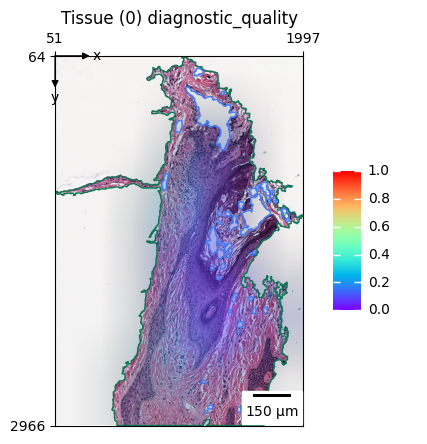

In [37]:
zs.pl.tiles(wsi, tissue_id="all",color="diagnostic_quality",cmap="rainbow",smooth=True, alpha=.5, vmin=0, vmax=1)

Extracting the patch features using a feature extractor (ResNet50)

In [38]:
import timm
timm.list_models()

['aimv2_1b_patch14_224',
 'aimv2_1b_patch14_336',
 'aimv2_1b_patch14_448',
 'aimv2_3b_patch14_224',
 'aimv2_3b_patch14_336',
 'aimv2_3b_patch14_448',
 'aimv2_huge_patch14_224',
 'aimv2_huge_patch14_336',
 'aimv2_huge_patch14_448',
 'aimv2_large_patch14_224',
 'aimv2_large_patch14_336',
 'aimv2_large_patch14_448',
 'bat_resnext26ts',
 'beit3_base_patch16_224',
 'beit3_giant_patch14_224',
 'beit3_giant_patch14_336',
 'beit3_large_patch16_224',
 'beit_base_patch16_224',
 'beit_base_patch16_384',
 'beit_large_patch16_224',
 'beit_large_patch16_384',
 'beit_large_patch16_512',
 'beitv2_base_patch16_224',
 'beitv2_large_patch16_224',
 'botnet26t_256',
 'botnet50ts_256',
 'caformer_b36',
 'caformer_m36',
 'caformer_s18',
 'caformer_s36',
 'cait_m36_384',
 'cait_m48_448',
 'cait_s24_224',
 'cait_s24_384',
 'cait_s36_384',
 'cait_xs24_384',
 'cait_xxs24_224',
 'cait_xxs24_384',
 'cait_xxs36_224',
 'cait_xxs36_384',
 'coat_lite_medium',
 'coat_lite_medium_384',
 'coat_lite_mini',
 'coat_lite_sma

In [39]:
zs.tl.feature_extraction(wsi,"resnet50")

model.safetensors: reconstructing file:   0%|          |  0.00B /  102MB            

model.safetensors: downloading bytes:           |  0.00B            

Output()

WSI: /content/CMU-1-Small-Region.svs
Reader: openslide
Dimensions: 2967×2220 (h×w), 1 Pyramid
Pixel physical size: 0.499 MPP
SpatialData object, with associated Zarr store: /content/CMU-1-Small-Region.zarr
├── Shapes
│     ├── 'dl-tissues': GeoDataFrame shape: (2, 2) (2D shapes)
│     ├── 'tile_overlap_0.1': GeoDataFrame shape: (34, 3) (2D shapes)
│     ├── 'tiles': GeoDataFrame shape: (29, 9) (2D shapes)
│     └── 'tissues': GeoDataFrame shape: (1, 51) (2D shapes)
└── Tables
      └── 'resnet50_tiles': AnnData (29, 2048)
with coordinate systems:
    ▸ 'global', with elements:
        dl-tissues (Shapes), tile_overlap_0.1 (Shapes), tiles (Shapes), tissues (Shapes)
with the following elements not in the Zarr store:
    ▸ resnet50_tiles (Tables)
    ▸ dl-tissues (Shapes)
    ▸ tiles (Shapes)
    ▸ tile_overlap_0.1 (Shapes)
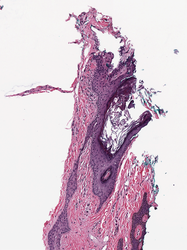

In [40]:
wsi

Aggregating the patch features after extracting them from the resnet50 model

In [41]:
zs.tl.feature_aggregation(wsi,"resnet50")

In [42]:
wsi["resnet50_tiles"]

AnnData object with n_obs × n_vars = 29 × 2048
    obs: 'tile_id', 'library_id'
    uns: 'spatialdata_attrs', 'agg_ops'
    varm: 'agg_slide'
    layers: None (.X)

In [43]:
wsi.fetch.features_anndata("resnet50")

AnnData object with n_obs × n_vars = 29 × 2048
    obs: 'tile_id', 'tissue_id', 'diagnostic_quality', 'visual_cleanliness', 'focus_issue', 'staining_issue', 'tissue_folding_present', 'misc_artifacts_present'
    uns: 'tile_spec', 'slide_properties'
    obsm: 'spatial'
    varm: 'agg_slide'
    layers: None (.X)

Saving work to disk

In [44]:
wsi.write()

WSI: /content/CMU-1-Small-Region.svs
Reader: openslide
Dimensions: 2967×2220 (h×w), 1 Pyramid
Pixel physical size: 0.499 MPP
SpatialData object, with associated Zarr store: /content/CMU-1-Small-Region.zarr
├── Shapes
│     ├── 'dl-tissues': GeoDataFrame shape: (2, 2) (2D shapes)
│     ├── 'tile_overlap_0.1': GeoDataFrame shape: (34, 3) (2D shapes)
│     ├── 'tiles': GeoDataFrame shape: (29, 9) (2D shapes)
│     └── 'tissues': GeoDataFrame shape: (1, 51) (2D shapes)
└── Tables
      └── 'resnet50_tiles': AnnData (29, 2048)
with coordinate systems:
    ▸ 'global', with elements:
        dl-tissues (Shapes), tile_overlap_0.1 (Shapes), tiles (Shapes), tissues (Shapes)
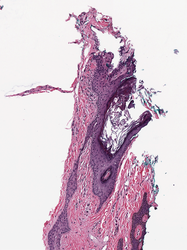

In [45]:
wsi